In [1]:
import sys
import os

import matplotlib.pyplot as plt

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from my_nn import (
    MLP,
    accuracy,
    load_mnist,
    train_epoch_sgd,
    train_epoch_bgd,
    build_optimizer_state,
)

In [2]:
x_train, y_train, x_test, y_test = load_mnist()

In [18]:
def train_model_bgd(hidden_dims, epochs):
    model = MLP(
        input_dim=784,
        hidden_dims=hidden_dims,
        num_classes=10,
        init_method="normal_small",
        dropout_p=0.0,
        seed=42,
    )

    train_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(1, epochs + 1):
        tl, ta = train_epoch_bgd(
            model,
            x_train,
            y_train,
            lr=1,
            l2_lambda=0.0,
        )
        logits_te = model.forward(x_test, train=False)
        te_acc = accuracy(logits_te, y_test)
        train_losses.append(tl)
        train_accs.append(ta)
        test_accs.append(te_acc)
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"epoch {epoch:3d}  train_loss={tl:.4f}  train_acc={ta:.4f}  test_acc={te_acc:.4f}"
            )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, epochs + 1), train_losses, label="train loss", color="C0")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax2 = ax.twinx()
    ax2.plot(
        range(1, epochs + 1), train_accs, label="train acc", color="C1", linestyle="--"
    )
    ax2.plot(range(1, epochs + 1), test_accs, label="test acc", color="C2")
    ax2.set_ylabel("accuracy")
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines], loc="center right")
    ax.set_title("train bgd process")
    fig.tight_layout()
    fig.savefig("./curve.png", dpi=150)

epoch   1  train_loss=2.3026  train_acc=0.1124  test_acc=0.1135
epoch   5  train_loss=2.3016  train_acc=0.1124  test_acc=0.1135
epoch  10  train_loss=2.3008  train_acc=0.1124  test_acc=0.1135
epoch  15  train_loss=2.3002  train_acc=0.1124  test_acc=0.1135
epoch  20  train_loss=2.2990  train_acc=0.1124  test_acc=0.1135
epoch  25  train_loss=2.2962  train_acc=0.1124  test_acc=0.1135
epoch  30  train_loss=2.2851  train_acc=0.2207  test_acc=0.2252
epoch  35  train_loss=2.1973  train_acc=0.2119  test_acc=0.2128
epoch  40  train_loss=1.8466  train_acc=0.3453  test_acc=0.3453
epoch  45  train_loss=2.2275  train_acc=0.2154  test_acc=0.2202
epoch  50  train_loss=2.2652  train_acc=0.2068  test_acc=0.2070
epoch  55  train_loss=1.9995  train_acc=0.3256  test_acc=0.3386
epoch  60  train_loss=1.7185  train_acc=0.3929  test_acc=0.3933
epoch  65  train_loss=1.6531  train_acc=0.4545  test_acc=0.4551
epoch  70  train_loss=2.3286  train_acc=0.1134  test_acc=0.1109
epoch  75  train_loss=1.8297  train_acc=

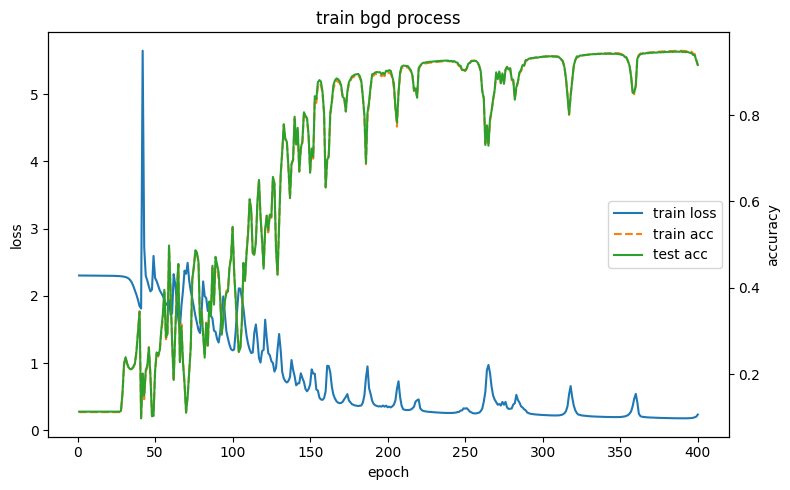

In [21]:
train_model_bgd([96, 64], 400)

In [6]:
def train_model_sgd(hidden_dims, epochs):
    model = MLP(
        input_dim=784,
        hidden_dims=hidden_dims,
        num_classes=10,
        init_method="normal_small",
        dropout_p=0.0,
        seed=42,
    )

    train_losses = []
    train_accs = []
    test_accs = []
    opt_state = build_optimizer_state(model, "sgd")

    for epoch in range(1, epochs + 1):
        tl, ta = train_epoch_sgd(
            model,
            x_train,
            y_train,
            batch_size=64,
            lr=1,
            l2_lambda=0.0,
            optimizer="sgd",
            opt_state=opt_state,
        )
        logits_te = model.forward(x_test, train=False)
        te_acc = accuracy(logits_te, y_test)
        train_losses.append(tl)
        train_accs.append(ta)
        test_accs.append(te_acc)
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"epoch {epoch:3d}  train_loss={tl:.4f}  train_acc={ta:.4f}  test_acc={te_acc:.4f}"
            )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, epochs + 1), train_losses, label="train loss", color="C0")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax2 = ax.twinx()
    ax2.plot(
        range(1, epochs + 1), train_accs, label="train acc", color="C1", linestyle="--"
    )
    ax2.plot(range(1, epochs + 1), test_accs, label="test acc", color="C2")
    ax2.set_ylabel("accuracy")
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines], loc="center right")
    ax.set_title("train sgd process")
    fig.tight_layout()
    fig.savefig("./curve.png", dpi=150)

epoch   1  train_loss=1.2056  train_acc=0.8334  test_acc=0.8360
epoch   5  train_loss=0.1894  train_acc=0.9483  test_acc=0.9434
epoch  10  train_loss=0.1360  train_acc=0.9633  test_acc=0.9536
epoch  15  train_loss=0.1083  train_acc=0.9646  test_acc=0.9528
epoch  20  train_loss=0.1024  train_acc=0.9540  test_acc=0.9413
epoch  25  train_loss=0.0950  train_acc=0.9721  test_acc=0.9580
epoch  30  train_loss=0.0932  train_acc=0.9741  test_acc=0.9588
epoch  35  train_loss=0.0931  train_acc=0.9723  test_acc=0.9545
epoch  40  train_loss=0.0816  train_acc=0.9742  test_acc=0.9553


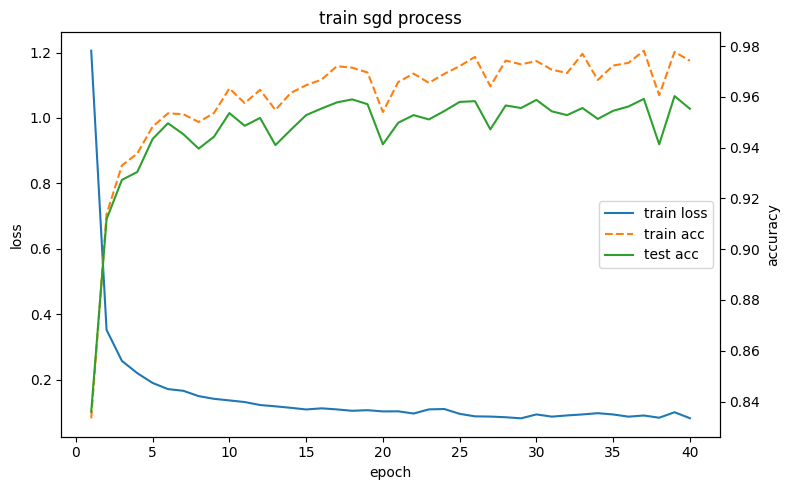

In [7]:
train_model_sgd([96, 64], 40)